# Finetune retrieval models для chebubrya memes bot

модели, которые будут дообучены и сравниваться друг с другом: `intfloat/multilingual-e5-base` and `BAAI/bge-m3`

## настраиваем ноутбук

In [1]:
!pip install -q sentence-transformers transformers tqdm openpyxl optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.4 MB/s eta 0:00:00


импорты

In [26]:
from __future__ import annotations
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Iterable
import ast
import json
import math
import random
import numpy as np
import pandas as pd
import torch
from sentence_transformers import InputExample, SentenceTransformer, losses
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

/tmp/ipykernel_11156/1243919351.py:12: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import InputExample, SentenceTransformer, losses


In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

настраиваем пути

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
DATASET_ROOT = Path('/content/drive/MyDrive/dataset')
MEMES_DATASET_PATH = Path('/content/drive/MyDrive/dataset/memes_retrieval.csv')
POS_NEG_PAIRS_DATASET = Path('/content/drive/MyDrive/dataset/reranker_pairs.csv')

OUTPUT_ROOT = DATASET_ROOT / 'retrieval_finetuned_dir'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MINI_MODEL_NAME = "intfloat/multilingual-e5-base"
LARGE_MODEL_NAME = "BAAI/bge-m3"

MODEL_NAMES = {
    "e5_base": "intfloat/multilingual-e5-base",
    "bge_m3": "BAAI/bge-m3"
}

USE_E5_PREFIXES = "e5" in MINI_MODEL_NAME.lower()
MEME_ID_COLUMN = "meme_id"
QUERY_COLUMN = "query"
POSITIVE_ID_COLUMN = "positive_meme_id"
NEGATIVE_IDS_COLUMN = "hard_negative_ids"

TEXT_FIELD_CONFIGS = {
    "embedding_only": ["embedding_text"],
    "embedding_plus_ocr": ["embedding_text", "ocr_text"],
    "full": ["embedding_text", "ocr_text", "semantic_description"],
}

In [6]:
OUTPUT_ROOT

PosixPath('/content/drive/MyDrive/dataset/retrieval_finetuned_dir')

In [7]:
def load_df(path:Path):
  return pd.read_csv(path, encoding='cp1251', sep=';')

загрузим и посмотрим на датасеты

In [8]:
meme_df = load_df(MEMES_DATASET_PATH)
pair_df = load_df(POS_NEG_PAIRS_DATASET)

print('meme_df', meme_df.shape, '\npair_df =', pair_df.shape)
display(meme_df.head(3))
display(pair_df.head(3))

meme_df (150, 14) 
pair_df = (3134, 6)


,meme_id,image_path,file_name,split,ocr_text,semantic_description,emotions,situations,humor_style,user_messages,search_queries,query_examples,safety_notes,embedding_text
0,meme_001,C:\Users\Lenovo\Desktop\dataset\train\images\m...,meme_001.jpg,train,ТГ: ШИЗЕЮ объебись,Мем выражает состояние сильного эмоционального...,"[""усталость"", ""шок"", ""перегрузка"", ""раздражени...","[""когда слишком много работы"", ""после долгого ...","[""ирония"", ""сарказм"", ""самоирония""]","[""Я просто не могу больше так работать."", ""Это...","[""усталость и перегрузка"", ""эмоциональное выго...","[""Я просто не могу больше так работать."", ""Это...",NaN,Мем выражает сильное эмоциональное перенапряже...
1,meme_002,C:\Users\Lenovo\Desktop\dataset\train\images\m...,meme_002.jpg,train,НАДОЕЛО ТИХО ХОДИТЬ,Мем выражает усталость от необходимости вести ...,"[""раздражение"", ""усталость"", ""фрустрация"", ""ре...","[""когда надоело скрывать свои мысли"", ""когда у...","[""ирония"", ""сарказм"", ""гипербола""]","[""Ну всё, хватит терпеть!"", ""Я больше не могу ...","[""усталость от сдержанности"", ""раздражение и ж...","[""Ну всё, хватит терпеть!"", ""Я больше не могу ...",NaN,Мем выражает усталость и раздражение от необхо...
2,meme_003,C:\Users\Lenovo\Desktop\dataset\train\images\m...,meme_003.jpg,train,МУСЯ ЭТО ТЫ О ЭТО МУСЯ С МУСЯТАМИ,Мем выражает забавное сравнение между одним че...,"[""юмор"", ""ирония"", ""легкость"", ""забава""]","[""когда кто-то говорит о себе и своих друзьях""...","[""ирония"", ""легкий сарказм"", ""игра слов""]","[""Ну ты и компания у себя!"", ""Вот это семейка ...","[""шутка про сходство с группой"", ""ирония про о...","[""Ну ты и компания у себя!"", ""Вот это семейка ...",NaN,Мем с текстом 'МУСЯ ЭТО ТЫ О ЭТО МУСЯ С МУСЯТА...


,target_meme_id,query,positive_meme_id,hard_negative_ids,source,hardness_reason
0,meme_001,"Я вообще не знаю как я еще работаю, уже схожу ...",meme_001,[],synthetic_positive_query,NaN
1,meme_001,После этого дня мне хочется просто убежать куд...,meme_001,[],synthetic_positive_query,NaN
2,meme_001,"Это настолько абсурдно, что я не могу, у меня ...",meme_001,[],synthetic_positive_query,NaN


## препроцессинг датасета

выборки будем делить по солбцу `positive_meme_id`, чтобы один и тот же целевой мем не попадал в разные выборки, для этого напишем функции, делящие айдишники и нормализующие данные

In [9]:
def normalize_text(value):
  if value is None:
    return ''
  if isinstance(value, float) and math.isnan(value):
    return ''
  text = str(value).strip()
  return '' if text.lower() == 'nan' else text

In [10]:
def parse_id_list(value: object) -> list[str]:
    if value is None:
        return []
    if isinstance(value, list):
        return [normalize_text(item) for item in value if normalize_text(item)]

    text = normalize_text(value)
    if not text or text == "[]":
        return []

    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(text)
        except Exception:
            continue
        if isinstance(parsed, list):
            return [normalize_text(item) for item in parsed if normalize_text(item)]

    for sep in [",", ";", "|"]:
        if sep in text:
            return [part.strip() for part in text.split(sep) if part.strip()]
    return [text]

так как модель e5 обучалась с префиксами `query:` и `passage:`, то мы добавим их, чтобы она лучше понимала текст, но с условием

In [11]:
def use_e5_prefixes(model_name: str) -> bool:
    return "e5" in model_name.lower()

In [12]:
def prefix_query(text: str, model_name: str) -> str:
    return f"query: {text}" if use_e5_prefixes(model_name) else text


def prefix_passage(text: str, model_name: str) -> str:
    return f"passage: {text}" if use_e5_prefixes(model_name) else text

функция, делающая словарь с ключом в виде ID мема и значением в виде объединенного текста всех текстовых колонок

In [13]:
def build_meme_text_by_id(df: pd.DataFrame, text_columns: Iterable[str]) -> dict[str, str]:
    missing = [column for column in text_columns if column not in df.columns]
    if missing:
        raise ValueError(f"Missing meme text columns: {missing}")

    mapping = {}
    for _, row in df.iterrows():
        meme_id = normalize_text(row.get(MEME_ID_COLUMN, ""))
        if not meme_id:
            continue

        parts = []
        for column in text_columns:
            value = normalize_text(row.get(column, ""))
            if value:
                parts.append(f"{column}: {value}")

        text = " | ".join(parts)
        if text:
            mapping[meme_id] = text
    return mapping

In [16]:
def split_by_positive_meme_id(df, val_ratio=0.2, test_ratio=0.1, seed=42):
    ids = sorted({
            normalize_text(value)
            for value in df['positive_meme_id'].tolist() if normalize_text(value)
        })
    rng = random.Random(seed)
    rng.shuffle(ids)
    test_count = max(1, int(len(ids) * test_ratio))
    val_count = max(1, int(len(ids) * val_ratio))

    test_ids = set(ids[:test_count])
    val_ids = set(ids[test_count:test_count + val_count])
    train_ids = set(ids[test_count + val_count:])

    return train_ids, val_ids, test_ids

In [17]:
def filter_pairs_by_positive_ids(df, ids):
    mask = df['positive_meme_id'].astype(str).str.strip().isin(ids)
    return df[mask].copy()

In [18]:
train_ids, val_ids, test_ids = split_by_positive_meme_id(
    pair_df,
    val_ratio=0.2,
    test_ratio=0.1,
    seed=42,
)

train_pair_df = filter_pairs_by_positive_ids(pair_df, train_ids)
val_pair_df = filter_pairs_by_positive_ids(pair_df, val_ids)
test_pair_df = filter_pairs_by_positive_ids(pair_df, test_ids)

In [19]:
print("train positive memes:", len(train_ids))
print("val positive memes:", len(val_ids))
print("test positive memes:", len(test_ids))

print("train pairs:", train_pair_df.shape)
print("val pairs:", val_pair_df.shape)
print("test pairs:", test_pair_df.shape)

train positive memes: 105
val positive memes: 29
test positive memes: 14
train pairs: (2227, 6)
val pairs: (604, 6)
test pairs: (303, 6)


кодируем все мемы-кандидаты, кодируем запросы, считаем similarity и проверяем позицию правильного `positive_meme_id`

In [20]:
# строим словарь правильных запросов для оценки
def build_eval_queries(df):
  queries = []
  for _, row in df.iterrows():
    query = normalize_text(row.get('query', ''))
    pos_id = normalize_text(row.get('positive_meme_id', row.get('target_meme_id', '')))
    if query and pos_id:
      queries.append({
          'query': query,
          'positive_meme_id': pos_id
      })
  return queries

## Evaluate

``` Tip
If you are unsure whether you should use encode(), encode_query(), or
encode_document(), your best bet is to use encode_query()
and encode_document() for Information Retrieval tasks with clear query
and document/passage distinction, and use encode() for all other tasks.
```

Буду использовать encode()

In [34]:
# пишем функцию для оценки предсказания бейзлайн модели
@torch.inference_mode()
def evaluate_retrieval_model(
    model, eval_queries, meme_text_by_id, model_name, top_ks=(1, 3, 5), batch_size = 64
):
  meme_ids = list(meme_text_by_id.keys())
  meme_texts = [prefix_passage(meme_text_by_id[meme_id], model_name) for meme_id in meme_ids]
  query_texts = [prefix_query(item["query"], model_name) for item in eval_queries]
  positive_ids = [item['positive_meme_id'] for item in eval_queries]

# вычисляем эмбеддинги
  passage_embeddings = model.encode(
      meme_texts,
      batch_size=batch_size,
      show_progress_bar=True,
      convert_to_numpy=True,
      normalize_embeddings=True
  )
  query_embeddings = model.encode(
      query_texts,
      batch_size=batch_size,
      show_progress_bar=True,
      convert_to_numpy=True,
      normalize_embeddings=True
  )
# считаем косинусное сходство запроса и мема
  scores = query_embeddings @ passage_embeddings.T
  max_k = max(top_ks)
  hits = {k: 0 for k in top_ks}
  reciprocal_rank_sum = 0.0
  failures = []

  for row_idx, positive_id in enumerate(positive_ids):
    ranked_indices = np.argsort(-scores[row_idx])[:max_k]
    ranked_ids = [meme_ids[idx] for idx in ranked_indices]
    rank = None
    for idx, meme_id in enumerate(ranked_ids, start=1):
      if meme_id == positive_id:
        rank = idx
        break
    if rank is not None:
      reciprocal_rank_sum += 1.0 / rank
      for k in top_ks:
        if rank <= k:
          hits[k] += 1
    else:
      failures.append({
          "query": eval_queries[row_idx]["query"],
          "positive_meme_id": positive_id,
          "top_ids": ranked_ids,
          "top_scores": [float(scores[row_idx, idx]) for idx in ranked_indices],
      })
  total = len(eval_queries)
  metrics = {"count": total, "mrr": reciprocal_rank_sum / total, "failures": failures}
  for k in top_ks:
      metrics[f"recall@{k}"] = hits[k] / total
  return metrics

In [24]:
# для негромоздкого вывода
def metrics_without_failures(metrics):
    return {key: value for key, value in metrics.items() if key != "failures"}

## Тест baseline по разным текстовым полям

In [30]:
import gc

In [35]:
baseline_rows = []

val_queries = build_eval_queries(val_pair_df)

for model_key, model_name in MODEL_NAMES.items():
    for text_config, text_columns in TEXT_FIELD_CONFIGS.items():
        print("=" * 80)
        print("baseline:", model_key, model_name, text_config)
        print("=" * 80)

        meme_text_by_id = build_meme_text_by_id(meme_df, text_columns)

        model = SentenceTransformer(model_name, device=DEVICE)
        model.max_seq_length = 512

        metrics = evaluate_retrieval_model(
            model=model,
            eval_queries=val_queries,
            meme_text_by_id=meme_text_by_id,
            model_name=model_name,
            top_ks=(1, 5, 10),
            batch_size=64,
        )

        baseline_rows.append({
            "stage": "baseline",
            "model_key": model_key,
            "model_name": model_name,
            "text_config": text_config,
            **metrics_without_failures(metrics),
        })

        del model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

baseline_table = pd.DataFrame(baseline_rows).sort_values("mrr", ascending=False)
baseline_table

baseline: e5_base intfloat/multilingual-e5-base embedding_only


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

,stage,model_key,model_name,text_config,count,mrr,recall@1,recall@5,recall@10
5,baseline,bge_m3,BAAI/bge-m3,full,604,0.638029,0.541391,0.768212,0.850993
3,baseline,bge_m3,BAAI/bge-m3,embedding_only,604,0.628504,0.529801,0.750000,0.836093
4,baseline,bge_m3,BAAI/bge-m3,embedding_plus_ocr,604,0.623115,0.531457,0.750000,0.834437
2,baseline,e5_base,intfloat/multilingual-e5-base,full,604,0.511326,0.410596,0.642384,0.764901
0,baseline,e5_base,intfloat/multilingual-e5-base,embedding_only,604,0.478353,0.374172,0.627483,0.748344
1,baseline,e5_base,intfloat/multilingual-e5-base,embedding_plus_ocr,604,0.476922,0.370861,0.635762,0.738411
7,baseline,rubert_tiny,cointegrated/rubert-tiny2,embedding_plus_ocr,604,0.297526,0.215232,0.410596,0.551325
8,baseline,rubert_tiny,cointegrated/rubert-tiny2,full,604,0.280650,0.192053,0.407285,0.523179
6,baseline,rubert_tiny,cointegrated/rubert-tiny2,embedding_only,604,0.279521,0.193709,0.382450,0.523179
9,baseline,rubert_base,DeepPavlov/rubert-base-cased,embedding_only,604,0.229192,0.155629,0.321192,0.442053


## Train часть

### build_train_examples

In [46]:
def build_train_examples(pair_df, meme_text_by_id, model_name):
  examples = []
  seen = set()
  for _, row in pair_df.iterrows():
    query = normalize_text(row.get('query', ''))
    positive_id = normalize_text(row.get('positive_meme_id', row.get('target_meme_id', '')))
    positive_text = meme_text_by_id.get(positive_id)
    if not query or not positive_text:
      continue
    key = (query, positive_id)
    if key in seen:
      continue
    seen.add(key)
    examples.append(InputExample(texts=[prefix_query(query, model_name), prefix_passage(positive_text, model_name)]))
  return examples

### Fine-tune

создаем класс для удобного проведения экспериментов

In [39]:
@dataclass(frozen=True)
class RetrievalExperiment:
    name: str
    model_key: str
    model_name: str
    text_config: str
    epochs: int = 3
    batch_size: int = 16
    learning_rate: float = 2e-5
    warmup_ratio: float = 0.1
    max_seq_length: int = 512

In [47]:
def train_one_experiment(exp, save_model=True):
  meme_text_by_id = build_meme_text_by_id(meme_df, TEXT_FIELD_CONFIGS[exp.text_config])
  train_examples = build_train_examples(train_pair_df, meme_text_by_id, exp.model_name)
  eval_queries = build_eval_queries(val_pair_df)

  train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=exp.batch_size)
  warmup_steps = math.ceil(len(train_dataloader) * exp.epochs * exp.warmup_ratio)

  output_dir = OUTPUT_ROOT / exp.name
  if output_dir.exists():
      shutil.rmtree(output_dir)

  output_dir.mkdir(parents=True, exist_ok=True)

  model = SentenceTransformer(exp.model_name, device=DEVICE)
  model.max_seq_length = exp.max_seq_length
  train_loss = losses.MultipleNegativesRankingLoss(model)

  model.fit(
      train_objectives=[(train_dataloader, train_loss)],
      epochs=exp.epochs,
      warmup_steps=warmup_steps,
      optimizer_params={"lr": exp.learning_rate},
      output_path=str(output_dir) if save_model else None,
      show_progress_bar=True,
      use_amp=torch.cuda.is_available()
  )

  if save_model:
      eval_model = SentenceTransformer(str(output_dir), device=DEVICE)
  else:
      eval_model = model

  eval_model.max_seq_length = exp.max_seq_length

  metrics = evaluate_retrieval_model(
      model=eval_model,
      eval_queries=eval_queries,
      meme_text_by_id=meme_text_by_id,
      model_name=exp.model_name,
      top_ks=(1, 5, 10),
      batch_size=64,
  )

  if save_model:
    (output_dir / "experiment_config.json").write_text(
        json.dumps(asdict(exp), ensure_ascii=False, indent=2), encoding="utf-8"
      )
    (output_dir / "metrics.json").write_text(
        json.dumps(metrics_without_failures(metrics), ensure_ascii=False, indent=2), encoding="utf-8"
      )
  result = {
      "stage": "finetuned",
      "experiment": exp.name,
      "model_path": str(output_dir) if save_model else None,
      **asdict(exp),
      **metrics_without_failures(metrics),
  }

  del model
  if save_model:
      del eval_model

  gc.collect()

  if torch.cuda.is_available():
    torch.cuda.empty_cache()

  return result

In [48]:
def objective(trial):
    model_key = trial.suggest_categorical("model_key", ["e5_base"])
    model_name = MODEL_NAMES[model_key]

    text_config = trial.suggest_categorical(
        "text_config",
        ["embedding_only", "embedding_plus_ocr", "full"]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-6,
        5e-5,
        log=True,
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [4, 8, 16]
    )

    epochs = trial.suggest_int(
        "epochs",
        1,
        3
    )

    warmup_ratio = trial.suggest_float(
        "warmup_ratio",
        0.0,
        0.2
    )

    max_seq_length = trial.suggest_categorical(
        "max_seq_length",
        [256, 384, 512]
    )

    exp = RetrievalExperiment(
        name=f"optuna_trial_{trial.number}_{model_key}_{text_config}",
        model_key=model_key,
        model_name=model_name,
        text_config=text_config,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        warmup_ratio=warmup_ratio,
        max_seq_length=max_seq_length,
    )

    try:
        result = train_one_experiment(exp, save_model=True)

    except RuntimeError as error:
        if "out of memory" in str(error).lower():
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            gc.collect()

            raise optuna.exceptions.TrialPruned("CUDA out of memory")

        raise error

    trial.set_user_attr("recall@1", result["recall@1"])
    trial.set_user_attr("recall@5", result["recall@5"])
    trial.set_user_attr("recall@10", result["recall@10"])
    trial.set_user_attr("mrr", result["mrr"])
    trial.set_user_attr("model_path", result["model_path"])

    return result["mrr"]

In [50]:
study = optuna.create_study(
    direction="maximize",
    study_name="retrieval_hparam_search_e5_only",
    storage=f"sqlite:///{OUTPUT_ROOT / 'optuna_study_e5_only.db'}",
    load_if_exists=True,
)

study.optimize(
    objective,
    n_trials=10,
    gc_after_trial=True,
)

[I 2026-04-26 13:51:52,643] A new study created in RDB with name: retrieval_hparam_search_e5_only


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.463884


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-26 14:48:53,395] Trial 9 finished with value: 0.6935686691895304 and parameters: {'model_key': 'e5_base', 'text_config': 'embedding_plus_ocr', 'learning_rate': 1.016260928895681e-05, 'batch_size': 8, 'epochs': 3, 'warmup_ratio': 0.06642369574624994, 'max_seq_length': 512}. Best is trial 0 with value: 0.7074339062335756.


In [51]:
optuna_rows = []

for trial in study.trials:
    if trial.value is None:
        continue

    row = {
        "stage": "optuna",
        "trial": trial.number,
        "mrr": trial.value,
        **trial.params,
    }

    for key, value in trial.user_attrs.items():
        row[key] = value

    optuna_rows.append(row)

train_table = pd.DataFrame(optuna_rows).sort_values("mrr", ascending=False)
train_table

,stage,trial,mrr,model_key,text_config,learning_rate,batch_size,epochs,warmup_ratio,max_seq_length,model_path,recall@1,recall@10,recall@5
0,optuna,0,0.707434,e5_base,full,0.000004,8,3,0.000097,256,/content/drive/MyDrive/dataset/retrieval_finet...,0.610927,0.928808,0.832781
3,optuna,3,0.693897,e5_base,embedding_only,0.000007,8,2,0.019023,512,/content/drive/MyDrive/dataset/retrieval_finet...,0.589404,0.923841,0.824503
6,optuna,6,0.693620,e5_base,embedding_only,0.000004,16,1,0.143914,384,/content/drive/MyDrive/dataset/retrieval_finet...,0.596026,0.907285,0.814570
9,optuna,9,0.693569,e5_base,embedding_plus_ocr,0.000010,8,3,0.066424,512,/content/drive/MyDrive/dataset/retrieval_finet...,0.589404,0.923841,0.834437
5,optuna,5,0.690255,e5_base,full,0.000010,4,3,0.108850,256,/content/drive/MyDrive/dataset/retrieval_finet...,0.596026,0.902318,0.819536
2,optuna,2,0.686804,e5_base,full,0.000003,4,3,0.178933,512,/content/drive/MyDrive/dataset/retrieval_finet...,0.584437,0.912252,0.819536
1,optuna,1,0.684297,e5_base,embedding_only,0.000001,8,2,0.043637,384,/content/drive/MyDrive/dataset/retrieval_finet...,0.581126,0.910596,0.807947
4,optuna,4,0.681059,e5_base,embedding_only,0.000007,4,2,0.066121,256,/content/drive/MyDrive/dataset/retrieval_finet...,0.574503,0.902318,0.821192
8,optuna,8,0.679598,e5_base,embedding_only,0.000001,4,2,0.061790,384,/content/drive/MyDrive/dataset/retrieval_finet...,0.576159,0.918874,0.809603
7,optuna,7,0.665361,e5_base,embedding_plus_ocr,0.000003,4,2,0.000843,256,/content/drive/MyDrive/dataset/retrieval_finet...,0.562914,0.897351,0.812914


Теперь лучшая e5:

In [52]:
best_e5_row = train_table.sort_values("mrr", ascending=False).iloc[0]

best_e5_model_path = Path(best_e5_row["model_path"])
best_e5_model_key = best_e5_row["model_key"]
best_e5_model_name = MODEL_NAMES[best_e5_model_key]
best_e5_text_config = best_e5_row["text_config"]
best_e5_max_seq_length = int(best_e5_row["max_seq_length"])

best_e5_row

,0
stage,optuna
trial,0
mrr,0.707434
model_key,e5_base
text_config,full
learning_rate,0.000004
batch_size,8
epochs,3
warmup_ratio,0.000097
max_seq_length,256


In [53]:
def evaluate_saved_model_on_split(
    model_path,
    model_key,
    model_name,
    text_config,
    max_seq_length,
    split_df,
    split_name="test",
    batch_size=64,
):
    meme_text_by_id = build_meme_text_by_id(
        meme_df,
        TEXT_FIELD_CONFIGS[text_config],
    )

    eval_queries = build_eval_queries(split_df)

    model = SentenceTransformer(str(model_path), device=DEVICE)
    model.max_seq_length = int(max_seq_length)

    metrics = evaluate_retrieval_model(
        model=model,
        eval_queries=eval_queries,
        meme_text_by_id=meme_text_by_id,
        model_name=model_name,
        top_ks=(1, 5, 10),
        batch_size=batch_size,
    )

    result = {
        "stage": "test_eval",
        "split": split_name,
        "model_key": model_key,
        "model_name": model_name,
        "text_config": text_config,
        "max_seq_length": int(max_seq_length),
        "model_path": str(model_path),
        **metrics_without_failures(metrics),
    }

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

Проверяем лучшую e5 на test:

In [54]:
best_e5_test_result = evaluate_saved_model_on_split(
    model_path=best_e5_model_path,
    model_key=best_e5_model_key,
    model_name=best_e5_model_name,
    text_config=best_e5_text_config,
    max_seq_length=best_e5_max_seq_length,
    split_df=test_pair_df,
    split_name="test",
    batch_size=64,
)

pd.DataFrame([best_e5_test_result])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

,stage,split,model_key,model_name,text_config,max_seq_length,model_path,count,mrr,recall@1,recall@5,recall@10
0,test_eval,test,e5_base,intfloat/multilingual-e5-base,full,256,/content/drive/MyDrive/dataset/retrieval_finet...,303,0.663263,0.567657,0.80198,0.877888


для bge-m3 создаем отдельный RetrievalExperiment

In [55]:
bge_exp = RetrievalExperiment(
    name="bge_m3_full_lr_1e5_bs2_ep1",
    model_key="bge_m3",
    model_name=MODEL_NAMES["bge_m3"],
    text_config="full",
    epochs=1,
    batch_size=2,
    learning_rate=1e-5,
    warmup_ratio=0.1,
    max_seq_length=512,
)

bge_result = train_one_experiment(bge_exp, save_model=True)
pd.DataFrame([bge_result])

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.064605


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

,stage,experiment,model_path,name,model_key,model_name,text_config,epochs,batch_size,learning_rate,warmup_ratio,max_seq_length,count,mrr,recall@1,recall@5,recall@10
0,finetuned,bge_m3_full_lr_1e5_bs2_ep1,/content/drive/MyDrive/dataset/retrieval_finet...,bge_m3_full_lr_1e5_bs2_ep1,bge_m3,BAAI/bge-m3,full,1,2,0.00001,0.1,512,604,0.715203,0.597682,0.874172,0.951987


Оценка дообученной bge-m3 на test

In [56]:
bge_test_result = evaluate_saved_model_on_split(
    model_path=bge_result["model_path"],
    model_key=bge_result["model_key"],
    model_name=bge_result["model_name"],
    text_config=bge_result["text_config"],
    max_seq_length=bge_result["max_seq_length"],
    split_df=test_pair_df,
    split_name="test",
    batch_size=32,
)

pd.DataFrame([bge_test_result])

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

,stage,split,model_key,model_name,text_config,max_seq_length,model_path,count,mrr,recall@1,recall@5,recall@10
0,test_eval,test,bge_m3,BAAI/bge-m3,full,512,/content/drive/MyDrive/dataset/retrieval_finet...,303,0.644093,0.544554,0.759076,0.884488


## сравнение Baseline и fine-tuned моделей

In [57]:
e5_baseline_table = baseline_table[baseline_table["model_key"] == "e5_base"].copy()
baseline_by_text_config = e5_baseline_table.set_index("text_config")

comparison_rows = []

for _, row in train_table.iterrows():
    text_config = row["text_config"]
    baseline = baseline_by_text_config.loc[text_config]

    comparison_rows.append({
        "experiment": f"trial_{row['trial']}",
        "text_config": text_config,

        "baseline_recall@1": baseline["recall@1"],
        "finetuned_recall@1": row["recall@1"],
        "delta_recall@1": row["recall@1"] - baseline["recall@1"],

        "baseline_recall@5": baseline["recall@5"],
        "finetuned_recall@5": row["recall@5"],
        "delta_recall@5": row["recall@5"] - baseline["recall@5"],

        "baseline_recall@10": baseline["recall@10"],
        "finetuned_recall@10": row["recall@10"],
        "delta_recall@10": row["recall@10"] - baseline["recall@10"],

        "baseline_mrr": baseline["mrr"],
        "finetuned_mrr": row["mrr"],
        "delta_mrr": row["mrr"] - baseline["mrr"],

        "learning_rate": row["learning_rate"],
        "batch_size": row["batch_size"],
        "epochs": row["epochs"],
        "warmup_ratio": row["warmup_ratio"],
        "max_seq_length": row["max_seq_length"],

        "model_path": row["model_path"],
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values("delta_mrr", ascending=False)
comparison_table

,experiment,text_config,baseline_recall@1,finetuned_recall@1,delta_recall@1,baseline_recall@5,finetuned_recall@5,delta_recall@5,baseline_recall@10,finetuned_recall@10,delta_recall@10,baseline_mrr,finetuned_mrr,delta_mrr,learning_rate,batch_size,epochs,warmup_ratio,max_seq_length,model_path
3,trial_9,embedding_plus_ocr,0.370861,0.589404,0.218543,0.635762,0.834437,0.198675,0.738411,0.923841,0.185430,0.476922,0.693569,0.216647,0.000010,8,3,0.066424,512,/content/drive/MyDrive/dataset/retrieval_finet...
1,trial_3,embedding_only,0.374172,0.589404,0.215232,0.627483,0.824503,0.197020,0.748344,0.923841,0.175497,0.478353,0.693897,0.215544,0.000007,8,2,0.019023,512,/content/drive/MyDrive/dataset/retrieval_finet...
2,trial_6,embedding_only,0.374172,0.596026,0.221854,0.627483,0.814570,0.187086,0.748344,0.907285,0.158940,0.478353,0.693620,0.215267,0.000004,16,1,0.143914,384,/content/drive/MyDrive/dataset/retrieval_finet...
6,trial_1,embedding_only,0.374172,0.581126,0.206954,0.627483,0.807947,0.180464,0.748344,0.910596,0.162252,0.478353,0.684297,0.205944,0.000001,8,2,0.043637,384,/content/drive/MyDrive/dataset/retrieval_finet...
7,trial_4,embedding_only,0.374172,0.574503,0.200331,0.627483,0.821192,0.193709,0.748344,0.902318,0.153974,0.478353,0.681059,0.202706,0.000007,4,2,0.066121,256,/content/drive/MyDrive/dataset/retrieval_finet...
8,trial_8,embedding_only,0.374172,0.576159,0.201987,0.627483,0.809603,0.182119,0.748344,0.918874,0.170530,0.478353,0.679598,0.201244,0.000001,4,2,0.061790,384,/content/drive/MyDrive/dataset/retrieval_finet...
0,trial_0,full,0.410596,0.610927,0.200331,0.642384,0.832781,0.190397,0.764901,0.928808,0.163907,0.511326,0.707434,0.196108,0.000004,8,3,0.000097,256,/content/drive/MyDrive/dataset/retrieval_finet...
9,trial_7,embedding_plus_ocr,0.370861,0.562914,0.192053,0.635762,0.812914,0.177152,0.738411,0.897351,0.158940,0.476922,0.665361,0.188439,0.000003,4,2,0.000843,256,/content/drive/MyDrive/dataset/retrieval_finet...
4,trial_5,full,0.410596,0.596026,0.185430,0.642384,0.819536,0.177152,0.764901,0.902318,0.137417,0.511326,0.690255,0.178929,0.000010,4,3,0.108850,256,/content/drive/MyDrive/dataset/retrieval_finet...
5,trial_2,full,0.410596,0.584437,0.173841,0.642384,0.819536,0.177152,0.764901,0.912252,0.147351,0.511326,0.686804,0.175478,0.000003,4,3,0.178933,512,/content/drive/MyDrive/dataset/retrieval_finet...


In [60]:
def evaluate_baseline_on_test(model_key, text_config, batch_size=64):
    model_name = MODEL_NAMES[model_key]

    meme_text_by_id = build_meme_text_by_id(
        meme_df,
        TEXT_FIELD_CONFIGS[text_config],
    )

    eval_queries = build_eval_queries(test_pair_df)

    model = SentenceTransformer(model_name, device=DEVICE)
    model.max_seq_length = 512

    metrics = evaluate_retrieval_model(
        model=model,
        eval_queries=eval_queries,
        meme_text_by_id=meme_text_by_id,
        model_name=model_name,
        top_ks=(1, 5, 10),
        batch_size=batch_size,
    )

    result = {
        "stage": "baseline",
        "split": "test",
        "model_key": model_key,
        "model_name": model_name,
        "text_config": text_config,
        "max_seq_length": 512,
        "model_path": None,
        **metrics_without_failures(metrics),
    }

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

In [61]:
bge_baseline_test_result = evaluate_baseline_on_test(
    model_key="bge_m3",
    text_config="full",
    batch_size=32,
)

final_comparison = pd.DataFrame([
    best_e5_test_result,
    bge_baseline_test_result,
    bge_test_result,
])

final_comparison[
    [
        "stage",
        "split",
        "model_key",
        "text_config",
        "count",
        "mrr",
        "recall@1",
        "recall@5",
        "recall@10",
        "max_seq_length",
    ]
].sort_values("mrr", ascending=False)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

,stage,split,model_key,text_config,count,mrr,recall@1,recall@5,recall@10,max_seq_length
0,test_eval,test,e5_base,full,303,0.663263,0.567657,0.801980,0.877888,256
2,test_eval,test,bge_m3,full,303,0.644093,0.544554,0.759076,0.884488,512
1,baseline,test,bge_m3,full,303,0.633487,0.547855,0.739274,0.782178,512


## Анализ ошибок лучшей retrieval-модели

In [62]:
best_row = train_table.sort_values("mrr", ascending=False).iloc[0]

best_model_path = Path(best_row["model_path"])
best_text_config = best_row["text_config"]
best_model_name = MODEL_NAMES[best_row["model_key"]]

best_meme_text_by_id = build_meme_text_by_id(
    meme_df,
    TEXT_FIELD_CONFIGS[best_text_config]
)

best_model = SentenceTransformer(str(best_model_path), device=DEVICE)
best_model.max_seq_length = int(best_row["max_seq_length"])

best_metrics = evaluate_retrieval_model(
    model=best_model,
    eval_queries=build_eval_queries(val_pair_df),
    meme_text_by_id=best_meme_text_by_id,
    model_name=best_model_name,
    top_ks=(1, 5, 10),
    batch_size=64,
)

print("best model:", best_model_path)
print(metrics_without_failures(best_metrics))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

best model: /content/drive/MyDrive/dataset/retrieval_finetuned_dir/optuna_trial_0_e5_base_full
{'count': 604, 'mrr': 0.7074339062335756, 'recall@1': 0.6109271523178808, 'recall@5': 0.8327814569536424, 'recall@10': 0.9288079470198676}


# Локальный тест

In [63]:
EXPORT_DIR = OUTPUT_ROOT / "exported_best_index"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

meme_ids = list(best_meme_text_by_id.keys())

meme_texts = [
    prefix_passage(best_meme_text_by_id[meme_id], best_model_name)
    for meme_id in meme_ids
]

passage_embeddings = best_model.encode(
    meme_texts,
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True,
)

np.savez_compressed(
    EXPORT_DIR / "passage_embeddings.npz",
    ids=np.array(meme_ids),
    embeddings=passage_embeddings
)

(EXPORT_DIR / "meme_text_by_id.json").write_text(
    json.dumps(best_meme_text_by_id, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("saved:", EXPORT_DIR)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

saved: /content/drive/MyDrive/dataset/retrieval_finetuned_dir/exported_best_index


In [64]:
def local_search(query, top_k=5):
    query_embedding = best_model.encode(
        [prefix_query(query, best_model_name)],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )[0]

    scores = passage_embeddings @ query_embedding
    top_indices = np.argsort(-scores)[:top_k]

    return pd.DataFrame([
        {
            "rank": rank,
            "meme_id": meme_ids[idx],
            "score": float(scores[idx]),
            "text": best_meme_text_by_id[meme_ids[idx]],
        }
        for rank, idx in enumerate(top_indices, start=1)
    ])

In [65]:
local_search("я сдала кт по мл", top_k=5)

,rank,meme_id,score,text
0,1,meme_008,0.327129,embedding_text: Мем выражает чувство внутренне...
1,2,meme_024,0.270106,embedding_text: Мем выражает восхищение и одоб...
2,3,meme_080,0.240510,embedding_text: Мем с надписью Саша и изображе...
3,4,meme_142,0.222588,embedding_text: Мем с надписью 'Аналитек Титек...
4,5,meme_120,0.222247,embedding_text: Мем выражает раздражение и агр...


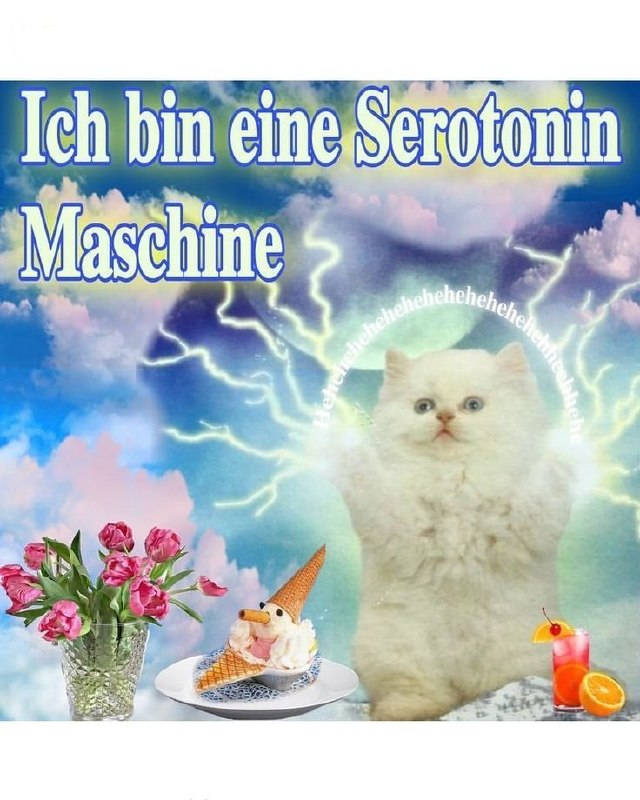